In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import pandas as pd 

In [2]:
df = pd.read_csv(r'C:\Users\LENOVO\OneDrive\Desktop\ML YT COURSE\archive\heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


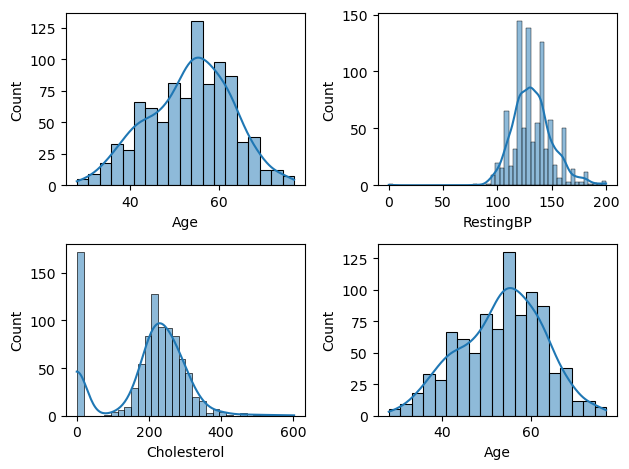

In [6]:
def plotting(var,num):
    plt. subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('Age',4)

plt.tight_layout()

In [7]:
ch_mean = df. loc [df ['Cholesterol'] != 0, 'Cholesterol'] .mean()

df ['Cholesterol'] = df ['Cholesterol' ]. replace(0, ch_mean)
df ['Cholesterol'] = df ['Cholesterol' ].round(2)


In [8]:
ch_mean = df. loc [df ['RestingBP'] != 0, 'RestingBP'] .mean()

df ['RestingBP'] = df ['RestingBP' ]. replace(0, ch_mean)
df ['RestingBP'] = df ['RestingBP' ].round(2)

In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [10]:
df_encoded.astype(int)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_col = ['Age','RestingBP','Cholesterol',	'FastingBS',	'MaxHR',	'Oldpeak'	]
df_encoded [numeric_col] = scaler.fit_transform(df_encoded [numeric_col])
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,-0.551341,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527192,-1.212938,-0.551341,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141317,0.719919,-0.551341,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303619,-0.574908,-0.551341,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.971022,-0.931454,-0.551341,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn. linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn. tree import DecisionTreeClassifier
from sklearn. svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [13]:
X = df_encoded.drop('HeartDisease',axis=1)
y = df_encoded['HeartDisease']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
models = {
"logistic Regression" : LogisticRegression(),
"KNN" : KNeighborsClassifier(),
"Naive Byeas": GaussianNB(),
"Decision tree" : DecisionTreeClassifier(),
"SVM" : SVC()

}
result = []

In [16]:
for name,model in models.items():
    model. fit(X_train_scaled , y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append ({
        'model': name,
        'Accuracy': round (acc, 4),
        "f1 score": round ( f1, 4)
    })

In [17]:
result

[{'model': 'logistic Regression', 'Accuracy': 0.8641, 'f1 score': 0.8792},
 {'model': 'KNN', 'Accuracy': 0.8533, 'f1 score': 0.8708},
 {'model': 'Naive Byeas', 'Accuracy': 0.8478, 'f1 score': 0.8614},
 {'model': 'Decision tree', 'Accuracy': 0.8043, 'f1 score': 0.8235},
 {'model': 'SVM', 'Accuracy': 0.8587, 'f1 score': 0.8762}]

In [18]:
import joblib
joblib. dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']

In [19]:
joblib. dump (models [ 'logistic Regression' ], 'logistic_Regression_heart.pkl')


['logistic_Regression_heart.pkl']

In [20]:

# 1. Fit scaler on X_train ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Fit KNN or LogisticRegression on X_train_scaled
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# 3. Save BOTH files together right after fitting
joblib.dump(knn_model, "knn_heart.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X_train.columns), "columns.pkl")

['columns.pkl']

In [22]:
import joblib
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load raw dataset
df = pd.read_csv(r'C:\Users\LENOVO\OneDrive\Desktop\ML YT COURSE\archive\heart.csv')

# 2. Impute zeros
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean).round(2)
bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, bp_mean).round(2)

# 3. One-hot encoding (DO NOT scale before splitting!)
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Fit fresh scaler on raw X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 6. Fit Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 7. Save clean artifacts to your project folder
joblib.dump(model, 'logistic_Regression_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'columns.pkl')

print("✅ Model, Scaler, and Columns successfully saved!")

✅ Model, Scaler, and Columns successfully saved!
